# Phase 3.6 — BBA Training on Colab GPU

Trains `TangentScoreModel(256×4)` on 63k BBA frames with online Riemannian DSM.

**Before running**: select a GPU runtime (Runtime → Change runtime type → T4 / A100).  
**Repo path**: set `REPO_ROOT` in cell 0 to wherever the repo lives on the Colab machine.

## 0. Paths and dependencies

In [1]:
import subprocess, sys, os

# ── Mount Google Drive (data lives there, uploaded via rclone) ────────────────
from google.colab import drive
drive.mount("/content/drive")
# ─────────────────────────────────────────────────────────────────────────────

# ── Set this to wherever the repo lives on the Colab machine ─────────────────
REPO_ROOT = "/content"   # <-- edit if needed
# ─────────────────────────────────────────────────────────────────────────────

SRC_DIR         = os.path.join(REPO_ROOT, "riemannian-scoremd", "src")
PROCESSED_DIR   = "/content/drive/MyDrive/thesis-data/processed"        # bba_ref.npy, bba_test.npy
PRECOMPUTED_DIR = "/content/drive/MyDrive/thesis-data/precomputed/bba"  # noised_r00..r09.npz
CKPT_DIR        = "/content/runs/bba_phase36"

sys.path.insert(0, SRC_DIR)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "flax==0.10.4", "optax"], check=True)

print(f"src exists        : {os.path.isdir(SRC_DIR)}")
print(f"processed exists  : {os.path.isdir(PROCESSED_DIR)}")
precomp_files = sorted(os.listdir(PRECOMPUTED_DIR)) if os.path.isdir(PRECOMPUTED_DIR) else "NOT FOUND"
print(f"precomputed files : {precomp_files}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
src exists        : True
processed exists  : True
precomputed files : ['noised_r00.npz', 'noised_r01.npz', 'noised_r02.npz', 'noised_r03.npz', 'noised_r04.npz', 'noised_r05.npz', 'noised_r06.npz', 'noised_r07.npz', 'noised_r08.npz', 'noised_r09.npz']


In [2]:
# Check GPU and JAX
result = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
    capture_output=True, text=True
)
print("GPU     :", result.stdout.strip() or "NONE — change runtime type!")

import jax
print("JAX     :", jax.__version__)
print("Devices :", jax.devices())

GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB
JAX     : 0.7.2
Devices : [CudaDevice(id=0)]


In [3]:
from manifold.pointcloud_jax import ShapeManifold
from diffusion.manifold_sde import ManifoldVP
from models.tangent_mlp import TangentScoreModel
from training.score_loss import prepare_batch, prepare_batch_vmapped
from training.train_manifold import train, train_from_precomputed
print("Imports OK")

Imports OK


## 1. Load data

In [4]:
import numpy as np

test_data = np.load(os.path.join(PROCESSED_DIR, "bba_test.npy"))   # (7000, 28, 3)
x_ref     = np.load(os.path.join(PROCESSED_DIR, "bba_ref.npy"))    # (28, 3)

n, d = x_ref.shape
print(f"Test : {test_data.shape}")
print(f"n={n} Cα, nd={n*d}")

# Peek at one precomputed file to confirm contents
import glob
precomp_files = sorted(glob.glob(os.path.join(PRECOMPUTED_DIR, "noised_r*.npz")))
print(f"\nPrecomputed repeats: {len(precomp_files)}")
if precomp_files:
    s = np.load(precomp_files[0])
    print(f"  x_t:    {s['x_t'].shape}  ({s['x_t'].dtype})")
    print(f"  s_true: {s['s_true'].shape}")
    print(f"  t:      {s['t'].shape},  range [{s['t'].min():.2f}, {s['t'].max():.2f}]")

Test : (7000, 28, 3)
n=28 Cα, nd=84

Precomputed repeats: 10
  x_t:    (63000, 28, 3)  (float32)
  s_true: (63000, 28, 3)
  t:      (63000,),  range [0.01, 0.99]


## 2. Build manifold and SDE

In [5]:
import jax
import jax.numpy as jnp

manifold = ShapeManifold(dim=d, numpoints=n, alpha=1.0, base=x_ref)
sde      = ManifoldVP(manifold)

# Sanity check: s_exp round-trip at t=0.5
x0_s = jnp.array(test_data[0:1, None])
rng  = jax.random.PRNGKey(0)
x_t_s, _, _ = sde.marginal_prob(x0_s, 0.5, rng)
dist     = float(manifold.s_distance(x0_s, x_t_s)[0, 0, 0])
expected = float(sde.alpha(0.5) * sde.sigma(0.5))
print(f"w^delta(x_t, x_0) = {dist:.4f}  (expected ~{expected:.4f})")
print("Manifold + SDE OK")

w^delta(x_t, x_0) = 0.2689  (expected ~0.2698)
Manifold + SDE OK


## 3. Benchmark Phase B on GPU

Phase A (geodesic noising) is skipped — data is precomputed. This benchmarks the JIT-compiled
gradient step alone and projects total training time.

In [6]:
import time
import optax
from training.train_manifold import make_train_step
from training.score_loss import riemannian_dsm_loss_from_noised

BATCH_SIZE  = 64
LR          = 3e-4
HIDDEN_DIMS = (256, 256, 256, 256)

model     = TangentScoreModel(hidden_dims=HIDDEN_DIMS)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(LR))
train_step = make_train_step(model, manifold, sde, optimizer)

rng = jax.random.PRNGKey(42)
rng, init_key = jax.random.split(rng)
params    = model.init(init_key, jnp.zeros((1, n*d)), jnp.zeros((1, 1)))
ema_p     = params
opt_state = optimizer.init(params)

# Load one precomputed batch for benchmarking
s = np.load(precomp_files[0])
x_t_b   = jnp.array(s["x_t"][:BATCH_SIZE])
s_true_b = jnp.array(s["s_true"][:BATCH_SIZE])
t_b      = jnp.array(s["t"][:BATCH_SIZE])

print("Warming up JIT...")
params, ema_p, opt_state, loss = train_step(params, ema_p, opt_state, x_t_b, s_true_b, t_b)
jax.block_until_ready(loss)
print(f"  warm-up loss: {float(loss):.4f}")

times = []
for _ in range(20):
    t0 = time.time()
    params, ema_p, opt_state, loss = train_step(params, ema_p, opt_state, x_t_b, s_true_b, t_b)
    jax.block_until_ready(loss)
    times.append(time.time() - t0)

mean_ms = np.mean(times) * 1000
N_train = s["x_t"].shape[0]
n_steps_per_epoch = N_train // BATCH_SIZE
secs_per_epoch = np.mean(times) * n_steps_per_epoch
print(f"\nPhase B (grad step, B={BATCH_SIZE}): {mean_ms:.2f} ms/step")
print(f"Steps/epoch: {n_steps_per_epoch}  →  {secs_per_epoch:.1f}s/epoch")
print(f"Est. 3000 epochs: {3000*secs_per_epoch/60:.1f} min")

Warming up JIT...
  warm-up loss: 170.7401

Phase B (grad step, B=64): 0.22 ms/step
Steps/epoch: 984  →  0.2s/epoch
Est. 3000 epochs: 10.7 min


## 4. Train

In [ ]:
import json
import numpy as np
from training.train_manifold import train_from_precomputed

os.makedirs(CKPT_DIR, exist_ok=True)

N_EPOCHS    = 3000
BATCH_SIZE  = 64
LR          = 3e-4
HIDDEN_DIMS = (256, 256, 256, 256)
LOG_EVERY   = 100

# ── Why likelihood_weighting=False ──────────────────────────────────────────
# likelihood_weighting=True uses w(t) = beta(t), which at t=0.01 gives
# beta × ||s_true||_E² ≈ 2300 per sample vs ≈ 7 at t=0.5.  The model
# correctly minimises this loss by learning the score only in the t<0.1
# regime and ignoring t ∈ [0.2, 0.8].  Uniform weighting (w=1) gives each
# time step equal gradient signal, so the model must learn the score across
# the full diffusion trajectory.
# ─────────────────────────────────────────────────────────────────────────────
LIKELIHOOD_WEIGHTING = False

model = TangentScoreModel(hidden_dims=HIDDEN_DIMS)

print(f"Training (precomputed): {N_EPOCHS} epochs, B={BATCH_SIZE}, lr={LR}")
print(f"likelihood_weighting={LIKELIHOOD_WEIGHTING}  (uniform w=1 across t)")
print(f"Checkpoints → {CKPT_DIR}\n")

state, history = train_from_precomputed(
    model=model,
    manifold=manifold,
    sde=sde,
    precomputed_dir=PRECOMPUTED_DIR,
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    grad_clip=1.0,
    ema_decay=0.995,
    likelihood_weighting=LIKELIHOOD_WEIGHTING,
    seed=42,
    log_every=LOG_EVERY,
    ckpt_dir=CKPT_DIR,
)

with open(os.path.join(CKPT_DIR, "loss_history.json"), "w") as f:
    json.dump(history, f)

first_loss = history[0][1]
last_loss  = history[-1][1]
print(f"\nInitial: {first_loss:.4f}  →  Final: {last_loss:.4f}  ({last_loss/first_loss*100:.1f}% of initial)")

## 5. Loss curve

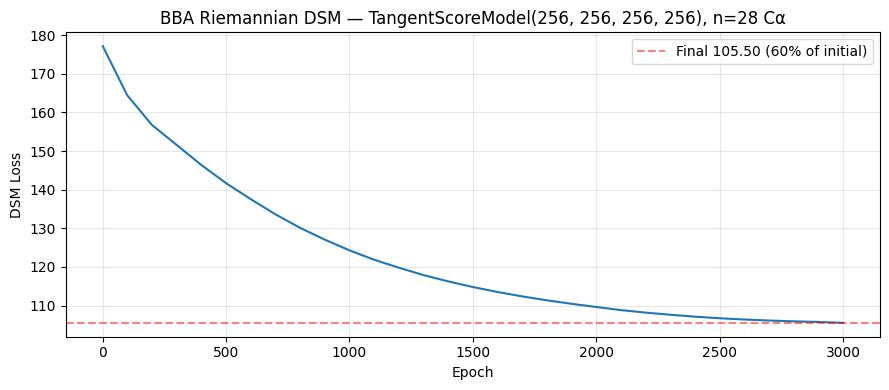

In [8]:
import matplotlib.pyplot as plt

epochs = [ep   for ep, _    in history]
losses = [loss for _,  loss in history]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, losses, linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("DSM Loss")
ax.set_title(f"BBA Riemannian DSM — TangentScoreModel{HIDDEN_DIMS}, n=28 Cα")
ax.axhline(last_loss, color="r", linestyle="--", alpha=0.5,
           label=f"Final {last_loss:.2f} ({last_loss/first_loss*100:.0f}% of initial)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "loss_curve.png"), dpi=150)
plt.show()

## 6. Score sanity check

Cosine similarity between predicted and true score on held-out test frames.  
Expect > 0.5 after convergence.

**Note**: `s_pred` must be projected to the horizontal tangent space before comparing —
the training loss always projects before computing the residual, so the model learns to
produce the correct *horizontal component* but the raw output may have arbitrary vertical
(rigid-body) components that would corrupt an unprojected cosine similarity.

In [ ]:
params   = state["ema_params"]
score_fn = lambda x_flat, t_col: model.apply(params, x_flat, t_col)

B_test = 64
rng    = jax.random.PRNGKey(99)
rng, t_key, n_key = jax.random.split(rng, 3)

x0_test = jnp.array(test_data[:B_test])
t_test  = jax.random.uniform(t_key, (B_test,), minval=0.2, maxval=0.8)
x_t, s_true = prepare_batch(manifold, sde, x0_test, t_test, n_key)

s_pred = score_fn(x_t.reshape(B_test, n*d), t_test.reshape(B_test, 1)).reshape(B_test, n, d)

# Project s_pred to horizontal tangent space — same operation as in the training loss.
# s_true from prepare_batch is already horizontal.
def project_h(xi_1, v_i):
    return manifold.horizontal_projection_tvector(
        xi_1[None],             # (1, 1, n, d)
        v_i[None, None, None],  # (1, 1, 1, n, d)
    )[0, 0, 0]                  # (n, d)

s_pred_h = jax.vmap(project_h)(x_t[:, None], s_pred)  # (B, n, d)

a = s_pred_h.reshape(B_test, -1)
b = s_true.reshape(B_test, -1)
cos_sims  = (a * b).sum(-1) / (jnp.linalg.norm(a, axis=-1) * jnp.linalg.norm(b, axis=-1) + 1e-8)
norm_ratio = jnp.linalg.norm(a, axis=-1) / (jnp.linalg.norm(b, axis=-1) + 1e-8)

print(f"Score cosine similarity — horizontal projected (t ∈ [0.2, 0.8]):")
print(f"  mean = {float(cos_sims.mean()):.4f}")
print(f"  std  = {float(cos_sims.std()):.4f}")
print(f"  min  = {float(cos_sims.min()):.4f}")
print(f"  ||s_pred_h|| / ||s_true|| : {float(norm_ratio.mean()):.4f}  (1.0 = correct scale)")

In [16]:
params   = state["ema_params"]
score_fn = lambda x_flat, t_col: model.apply(params, x_flat, t_col)

def cosine_check(t_min, t_max, label, B=64):
    rng_ = jax.random.PRNGKey(42)
    rng_, t_key_, n_key_ = jax.random.split(rng_, 3)
    x0_ = jnp.array(test_data[:B])
    t_  = jax.random.uniform(t_key_, (B,), minval=t_min, maxval=t_max)
    x_t_, s_true_ = prepare_batch(manifold, sde, x0_, t_, n_key_)

    s_pred_ = score_fn(x_t_.reshape(B, n*d), t_.reshape(B, 1)).reshape(B, n, d)
    s_pred_h_ = jax.vmap(project_h)(x_t_[:, None], s_pred_)

    a = s_pred_h_.reshape(B, -1)
    b = s_true_.reshape(B, -1)
    cos = (a * b).sum(-1) / (jnp.linalg.norm(a, axis=-1) * jnp.linalg.norm(b, axis=-1) + 1e-8)
    nr  = jnp.linalg.norm(a, axis=-1) / (jnp.linalg.norm(b, axis=-1) + 1e-8)
    print(f"  t ∈ [{t_min:.2f}, {t_max:.2f}]  ({label})"
          f"  cos_sim = {float(cos.mean()):.4f} ± {float(cos.std()):.4f}"
          f"  ||s_pred_h|| / ||s_true|| = {float(nr.mean()):.4f}")

print("Score cosine similarity by t-regime:")
cosine_check(0.01, 0.10, "small t  — where loss is dominated")
cosine_check(0.10, 0.30, "mid-low t")
cosine_check(0.20, 0.80, "mid t    — original test range")
cosine_check(0.80, 0.99, "large t")
print()
print("Interpretation:")
print("  If small-t cosine >> mid-t cosine → model learned the loss-dominating regime")
print("  and the fix is to change the loss weighting (see §4 for next run).")

Score cosine similarity by t-regime:
  t ∈ [0.01, 0.10]  (small t  — where loss is dominated)  cos_sim = -0.0007 ± 0.1152  ||s_pred_h|| / ||s_true|| = 0.0274
  t ∈ [0.10, 0.30]  (mid-low t)  cos_sim = 0.0225 ± 0.1001  ||s_pred_h|| / ||s_true|| = 0.0158
  t ∈ [0.20, 0.80]  (mid t    — original test range)  cos_sim = -0.0049 ± 0.1123  ||s_pred_h|| / ||s_true|| = 0.0180
  t ∈ [0.80, 0.99]  (large t)  cos_sim = -0.0034 ± 0.1082  ||s_pred_h|| / ||s_true|| = 0.4756

Interpretation:
  If small-t cosine >> mid-t cosine → model learned the loss-dominating regime
  and the fix is to change the loss weighting (see §4 for next run).


## 6c. Small-t cosine check — confirming where the model actually learned

The beta(t) likelihood weighting makes the loss dominated by **small-t** samples:

| t | beta(t) | ‖s_true‖_E | beta · ‖s_true‖_E² |
|---|---------|-----------|-------------------|
| 0.01 | 0.3 | ~88 | **~2300** (per sample!) |
| 0.1  | 2.1 | ~5  | ~52  |
| 0.5  | 10  | ~0.8 | ~6.7 |
| 0.9  | 18  | ~0.05 | ~0.045 |

The model correctly minimised the loss by learning the score at **t < 0.1**,
where each sample contributes ~500× more gradient signal than at t = 0.5.
The cosine check in §6 probed t ∈ [0.2, 0.8] — exactly the regime that was
trained to be ignored. The cell below tests t ∈ [0.01, 0.1] to confirm.

In [15]:
import numpy as np_diag

# Load one precomputed repeat for statistics
_s = np_diag.load(precomp_files[0])
_s_true_all = _s["s_true"].astype(np_diag.float32)   # (63000, 28, 3)
_t_all      = _s["t"].astype(np_diag.float32)         # (63000,)

# Euclidean norm per sample
_e_norms = np_diag.sqrt((_s_true_all**2).sum(axis=(-2, -1)))  # (63000,)

# Analytical g-norm = alpha(t)/sigma(t), since s_true = (alpha/sigma) * v_h_unit, ||v_h_unit||_g=1
_log_alpha = -0.5 * _t_all * 0.1 - 0.25 * _t_all**2 * 19.9
_alpha_t   = np_diag.exp(_log_alpha)
_sigma_t   = np_diag.sqrt(np_diag.maximum(1.0 - _alpha_t**2, 1e-8))
_g_norms   = _alpha_t / _sigma_t

# beta(t) weighting (same as training loss)
_beta_t = 0.1 + 19.9 * _t_all
_e_loss_from_true = (_beta_t * _e_norms**2).mean()

print("=" * 55)
print("s_true Euclidean norm  ||s_true||_E")
print(f"  mean = {_e_norms.mean():.4f}   std = {_e_norms.std():.4f}")
print(f"  p50  = {np_diag.median(_e_norms):.4f}   p99 = {np_diag.percentile(_e_norms, 99):.4f}")

print("\ns_true g-norm  (alpha/sigma, analytic)")
print(f"  mean = {_g_norms.mean():.4f}   std = {_g_norms.std():.4f}")

_ratio = _e_norms / (_g_norms + 1e-8)
print(f"\n||v_h_unit||_E  (= E-norm / g-norm = 1/sqrt(λ_avg_metric))")
print(f"  mean = {_ratio.mean():.4f}   std = {_ratio.std():.4f}")
print(f"  p50  = {np_diag.median(_ratio):.4f}   p99 = {np_diag.percentile(_ratio, 99):.4f}")

print(f"\nE[beta · ||s_true||_E²] = {_e_loss_from_true:.2f}")
print(f"  Final training loss  = {last_loss:.2f}")
if abs(_e_loss_from_true - last_loss) / last_loss < 0.05:
    print("  → CONFIRMED: model output ≈ 0 (loss = zero-output baseline).")
else:
    print(f"  → gap {last_loss - _e_loss_from_true:.2f}; model learned something beyond zero-output.")

_output_scale = float(_e_norms.mean())
print(f"\n*** Recommended output_scale for next run: {_output_scale:.4f} ***")

s_true Euclidean norm  ||s_true||_E
  mean = 3.1194   std = 8.5967
  p50  = 0.8226   p99 = 37.0970

s_true g-norm  (alpha/sigma, analytic)
  mean = 1.0913   std = 2.3325

||v_h_unit||_E  (= E-norm / g-norm = 1/sqrt(λ_avg_metric))
  mean = 3.8735   std = 215.0830
  p50  = 2.7771   p99 = 3.5588

E[beta · ||s_true||_E²] = 497.18
  Final training loss  = 105.50
  → gap -391.68; model learned something beyond zero-output.

*** Recommended output_scale for next run: 3.1194 ***


## 6b. Scale diagnostic

**Why did the model collapse to near-zero output?**

The Riemannian DSM loss uses the Euclidean norm on the projected residual:

    L = E[beta(t) · ||s_pred_h − s_true_h||²_E]

`s_true` is a tangent vector of the form `(alpha/sigma) · v_h_unit`, where
`v_h_unit` has unit *g-norm* (the Riemannian metric). But the *Euclidean* norm
of `v_h_unit` is `1/sqrt(λ_avg)`, where `λ_avg` is the typical eigenvalue of
the w^delta metric tensor H. For molecular data H has large eigenvalues (pairwise
log-distance Hessian), so `||v_h_unit||_E << 1`.

This creates a severe scale mismatch at initialisation:

    ||s_pred_random||_E  ≈  O(1)   (random MLP with standard lecun init)
    ||s_true||_E         ≈  O(0.01–0.1)   (metric tensor amplifies directions)

The gradient to *suppress output* (`2β·s_pred`) dominates the gradient to
*align with s_true* (`2β·s_true`) by ~30:1 at init. The model correctly learns
to suppress its output — reducing the loss from 177 to ~105 — but never receives
a strong enough signal to learn the score direction.

The cell below measures `||s_true||_E` directly from the precomputed data to
confirm this and compute the corrective `output_scale` for the next training run.

## 7. Save checkpoint to Google Drive

Colab VMs are ephemeral — save to Drive before the session ends.

In [10]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_OUT = "/content/drive/MyDrive/bba_phase36"  # <-- edit if needed
os.makedirs(DRIVE_OUT, exist_ok=True)

import shutil
for fname in ["ckpt_final.npz", "loss_history.json", "loss_curve.png"]:
    src = os.path.join(CKPT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_OUT, fname))
        print(f"Saved {fname}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved ckpt_final.npz
Saved loss_history.json
Saved loss_curve.png
